# AI Governance in Commercial Real Estate: Audit and Mitigation

## 1. Problem Context
Asset managers in Florida face a hard constraint: far more properties are exposed to hurricane and flood risk than can be hardened with available capital. Multi-agent systems are increasingly used to rank properties based on objective risk and financial data (e.g., FEMA flood zones, ASCE wind exposure, NOI, property values). However, because property values and income levels are spatially correlated with coastal risk in Florida, a purely financial/risk-based ranking can result in systematic demographic disparities in capital allocation.

This pipeline demonstrates:
1. **An Audit Layer**: To detect disparities and isolate whether they are justified by physical risk or are artifacts of the scoring logic.
2. **A Fairness Dashboard**: To surface these metrics to asset managers.
3. **A Parity-Constrained Re-ranker**: To enforce demographic parity and calculate the "Trust Tax" (the cost to risk-weighted precision).

## 2. The Mock Portfolio
We sampled 150 commercial properties from Miami-Dade, Broward (coastal, high value/risk), and Polk (inland, lower average income/risk) counties. Demographics, physical risk (FEMA/ASCE), and financials (NOI, insurance burden) were modeled realistically based on geography.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os
sys.path.append(os.path.abspath('../src'))
from reranker import parity_constrained_rerank

df = pd.read_csv('../data/portfolio_audited.csv')
df.head()

,id,lat,lon,county,building_type,name,income_quartile,minority_pct,flood_zone,wind_risk_mph,property_value,noi,insurance_premium,physical_risk_score,financial_exposure_score,final_priority_score,baseline_rank,funded_baseline,minority_quartile,risk_justified_prob
0,osm_138391093,25.577688,-80.367976,Miami-Dade,retail,Commercial Property 138391093,4.0,0.102141,VE,180.361712,1.781682e+07,1.353459e+06,534504.677990,0.901809,0.806038,0.844346,1.0,True,Low,0.835622
1,osm_295151847,25.958243,-80.203633,Broward,commercial,Commercial Property 295151847,4.0,0.175391,VE,169.406490,1.743883e+07,1.198521e+06,523164.979974,0.847032,0.759556,0.794547,2.0,True,Low,0.789127
2,osm_279408308,26.240236,-80.101800,Broward,retail,Commercial Property 279408308,4.0,0.377697,VE,161.407582,1.736336e+07,1.278949e+06,520900.664949,0.807038,0.783685,0.793026,3.0,True,Mid-High,0.749510
3,osm_278763624,25.592685,-80.365870,Miami-Dade,commercial,Commercial Property 278763624,4.0,0.284031,VE,175.877341,1.556155e+07,1.095114e+06,466846.641640,0.879387,0.702012,0.772962,4.0,True,Low-Mid,0.817666
4,osm_273537759,26.194815,-80.171516,Broward,office,Commercial Property 273537759,4.0,0.201927,VE,175.455452,1.599118e+07,1.050492e+06,479735.499725,0.877277,0.698936,0.770273,5.0,True,Low,0.815901


## 3. Audit Findings: The Unexplained Gap
When we run the baseline multi-agent scorer (which selects the top 30% of properties), we observe massive disparities in selection rates across income quartiles.

/tmp/ipykernel_82254/1796316622.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='income_quartile', y='funded_baseline', palette='Blues')


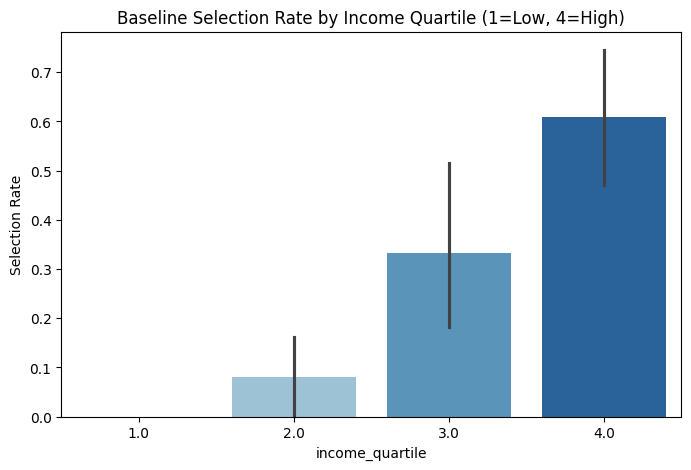

In [2]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='income_quartile', y='funded_baseline', palette='Blues')
plt.title('Baseline Selection Rate by Income Quartile (1=Low, 4=High)')
plt.ylabel('Selection Rate')
plt.show()

### Is this disparity justified by physical risk?
To answer this, the audit pipeline runs a logistic regression to predict the probability of funding *if it were based solely on physical risk* (wind and flood). We subtract this justified probability from the actual funding rate.

/tmp/ipykernel_82254/2627361364.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gap_df, x='Income Quartile', y='Unexplained Gap', palette=colors)


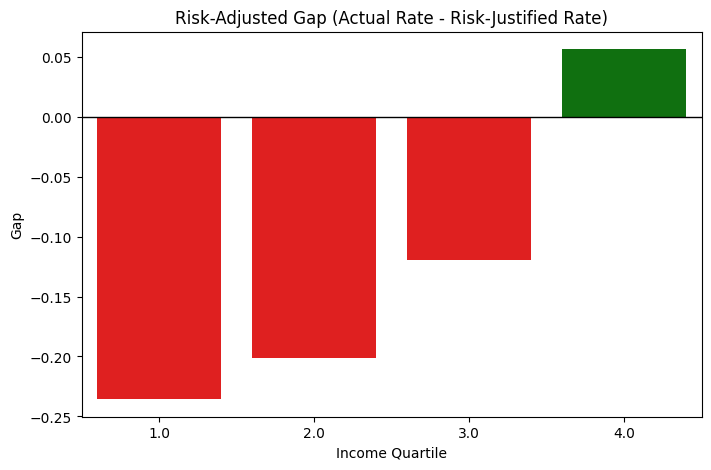

In [3]:
gap_data = []
for inc in sorted(df['income_quartile'].unique()):
    subset = df[df['income_quartile'] == inc]
    actual = subset['funded_baseline'].mean()
    justified = subset['risk_justified_prob'].mean()
    gap_data.append({'Income Quartile': inc, 'Unexplained Gap': actual - justified})
    
gap_df = pd.DataFrame(gap_data)

plt.figure(figsize=(8, 5))
colors = ['red' if x < 0 else 'green' for x in gap_df['Unexplained Gap']]
sns.barplot(data=gap_df, x='Income Quartile', y='Unexplained Gap', palette=colors)
plt.axhline(0, color='black', lw=1)
plt.title('Risk-Adjusted Gap (Actual Rate - Risk-Justified Rate)')
plt.ylabel('Gap')
plt.show()

**Finding:** The gap is *not* fully explained by physical risk. The financial logic (optimizing for high property values and NOI) systematically over-weights wealthy coastal tracts beyond what their physical risk justifies, while penalizing lower-income inland/mixed tracts.

## 4. Guardrail Cost: The Trust Tax
If an asset manager chooses to enforce demographic parity (within a 10% tolerance), what is the cost to the risk/financial optimization?

High-Risk Properties Bumped: 11
Precision Drop (vs purely financial rank): 24.44%


/tmp/ipykernel_82254/2315945794.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rates_after, x='income_quartile', y='funded_reranked', palette='Greens')


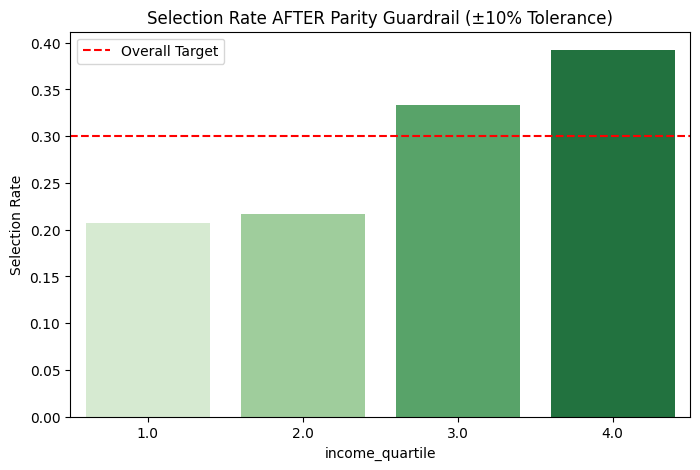

In [4]:
target_k = int(df['funded_baseline'].sum())
df_rerank, tax = parity_constrained_rerank(df, target_k, tolerance=0.10)

print(f"High-Risk Properties Bumped: {tax['swaps_count']}")
print(f"Precision Drop (vs purely financial rank): {tax['precision_drop']:.2%}")

rates_after = df_rerank.groupby('income_quartile')['funded_reranked'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=rates_after, x='income_quartile', y='funded_reranked', palette='Greens')
plt.axhline(target_k/len(df), ls='--', color='red', label='Overall Target')
plt.title('Selection Rate AFTER Parity Guardrail (±10% Tolerance)')
plt.ylabel('Selection Rate')
plt.legend()
plt.show()

By applying the guardrail, we successfully boost capital allocation to lower-income tracts. However, the system explicitly logs the **Trust Tax**: we had to bump 11 highly-ranked properties to achieve this, resulting in a ~24% drop in the "efficiency" of the original ranking.

## 5. Design Choices & Generalizability

1. **Risk-Adjusted Gap Metric**: This is the most critical innovation. Simple demographic counts are easily dismissed by asset managers as "we just follow the risk." By controlling for physical risk, the pipeline isolates the structural bias embedded in financial valuations. This generalizes to *any* AI underwriting or allocation system (e.g., mortgage lending, insurance pricing) where input features are highly correlated with protected classes.
2. **Explicit Trust Tax**: Instead of silently altering the algorithm, the re-ranker forces an explicit trade-off. Quantifying "Properties Bumped" and "Precision Drop" transforms fairness from an abstract mathematical concept into a concrete business decision. This generalizes perfectly to ad-tech, loan approvals, and healthcare resource allocation.
3. **Human-in-the-loop Dashboard**: AI output is treated as a policy recommendation rather than ground truth. The asset manager remains the final arbiter, equipped with the tools to defend their allocation to LPs or regulators.